# Brand-Level Sales Analysis

Extracts brand names from product descriptions (handling two-word brands
and raw ingredients separately), then analyzes market share, growth
trends, positioning, and head-to-head competitor comparisons.

**Input:** `data/processed/cleaned_processed_royal_sales_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\shahul\Downloads\royal_store_cleaned")
df['Date'] = pd.to_datetime(df['Date'])
df_sales = df[df['IsReturn'] == False].copy()

print(f"Total records   : {len(df):,}")
print(f"Sales records   : {len(df_sales):,}")
print(f"Unique products : {df_sales['Product Name'].nunique():,}")
print(f"Date range      : {df_sales['Date'].min().date()} → {df_sales['Date'].max().date()}")

Total records   : 130,553
Sales records   : 130,431
Unique products : 4,610
Date range      : 2025-04-01 → 2025-07-08


## 1. Brand Extraction — Exploration
Products don't have a clean "brand" column, so brand is inferred from the
first word(s) of the product name. First, explore what prefixes are common.

In [2]:
# Extract first word of every product
first_words = df_sales['Product Name'].str.split().str[0]
word_freq = first_words.value_counts()

# Words appearing in 3+ products = likely a brand prefix
likely_brands = word_freq[word_freq >= 3].index.tolist()

print(f"Likely brand prefixes found : {len(likely_brands)}")
print(f"\nTop 40 brand prefixes by frequency:")
print(word_freq[word_freq >= 3].head(40))

Likely brand prefixes found : 973

Top 40 brand prefixes by frequency:
Product Name
AROKYA         5347
BRI            4554
ARUN           4392
IDLY           3277
SAKTHI         3173
AACHI          3152
SURF           2414
EGG            1801
SF             1767
AASHIRVAAD     1521
HATSUN         1448
PARRYS         1377
ANIL           1358
GOLDWINNER     1263
PASI           1186
SRI            1109
RICE           1082
ULUNTHAM       1070
VIM            1058
CINTHOL        1029
COLGATE         973
THUVARAM        949
KS              896
POONDU          894
RSM             873
RIN             870
CLINIC          865
DABUR           809
BADAM           782
DAIRY           782
VARUKADALAI     747
PATTAI          723
JEERAGAM        709
MUNTHIRI        708
COMFORT         703
AVT             684
GOOD            666
PEN             656
MR.GOLD         649
SAMBA           638
Name: count, dtype: int64


In [6]:
# Check what products these ambiguous prefixes belong to
check_brands = ['SURF', 'CLINIC', 'GOOD', 'DAIRY', 'SRI',
                'BRI', 'SF', 'PASI', 'KS', 'RSM', 'PATTAI']

for prefix in check_brands:
    products = df_sales[df_sales['Product Name'].str.startswith(prefix)][
        'Product Name'].value_counts().head(5)
    print(f"\n{prefix}:")
    print(products.to_string())


SURF:
Product Name
SURF EXCEL SOAP 250GM    599
SURF EXCEL SOAP 150GM    503
SURF EXCEL 65GM          358
SURF EXCEL MRP 10        207
SURF EXCEL 200*4 PAK     141

CLINIC:
Product Name
CLINIC PLUS MRP.1                 595
CLINIC PLUS EGG                   207
CLINIC PLUS AD SHAMP 80ML          19
CLINIC PLUS 175ML                   9
CLINIC PLAS +HIBISCUS MRP 1.00      9

GOOD:
Product Name
GOOD DAY MRP 5.00 BAG    200
GOOD DAY CASHEW 58G      145
GOOD HOME SCRUBBER        91
GOOD NIGHT LIQUID         89
GOOD KNIGHT 10+4          38

DAIRY:
Product Name
DAIRY MILK CHOCOLATE RS 10/-    298
DAIRY MILK 21G MRP 20           158
DAIRY MILK 5.5G MRP5             81
DAIRY MILK MRP 45.00             47
DAIRY MILK CHO-FAMILY -100       39

SRI:
Product Name
SRI AMMAN MURUKU       1105
SRI GANGA SAMBIRANI       4

BRI:
Product Name
BRI MARIE GOLD 73GM       420
BRI MILK 73.5GM           378
BRI MILK CLASSIC 115GM    243
BRI BROWNIE CAKE 50GM     227
BRI 50+50 MRP 10.00       205

SF:
Product 

In [7]:
check_brands2 = ['ULUNTHAM', 'THUVARAM', 'BADAM', 'PATTAI',
                 'JEERAGAM', 'MUNTHIRI', 'SAMBA', 'RICE',
                 'IDLY', 'EGG', 'POONDU', 'VARUKADALAI']

for prefix in check_brands2:
    products = df_sales[df_sales['Product Name'].str.startswith(prefix)][
        'Product Name'].value_counts().head(5)
    print(f"\n{prefix}:")
    print(products.to_string())


ULUNTHAM:
Product Name
ULUNTHAM PARUPPU 500GM    450
ULUNTHAM PARUPPU 1KG      394
ULUNTHAM PARUPPU 250GM    226

THUVARAM:
Product Name
THUVARAM PARUPPU 1KG        346
THUVARAM PARUPPU 500G       342
THUVARAM PARUPPU 250G       252
THUVARAM PARUPPU 1KG SPL      9

BADAM:
Product Name
BADAM MILK 200ML    253
BADAM N 50GM PAK    133
BADAM ST 100GM       97
BADAM PISIN 100G     69
BADAM PISIN  50G     69

PATTAI:
Product Name
PATTAI SET MRP 10.00    344
PATTAI 25G              137
PATTAI SURUL 10GM       126
PATTAI 50GM              67
PATTAI SURUL 25GM        20

JEERAGAM:
Product Name
JEERAGAM 50GM      334
JEERAGAM 100GM     314
JEERAGAM 250 GM     61

MUNTHIRI:
Product Name
MUNTHIRI  25GM        285
MUNTHIRI 50GM N       216
MUNTHIRI 100GM         89
MUNTHIRI ST 100GM      70
MUNTHIRI NO1 250GM     39

SAMBA:
Product Name
SAMBA MILAKAI  100GM    417
SAMBA MILAKA 250GM      105
SAMBA MILAKA 1KG         47
SAMBA MILAKA 500GM       36
SAMBA MILAKA KG          33

RICE:
Product Name
RIC

## 2. Brand Extraction Logic
Handle three cases: known two-word brands, raw ingredients (grouped as a
category rather than a "brand"), and everything else (first word = brand).

In [8]:
# Two-word brands that need special handling
two_word_brands = [
    'SURF EXCEL', 'CLINIC PLUS', 'GOOD DAY', 'GOOD HOME',
    'GOOD KNIGHT', 'GOOD NIGHT', 'DAIRY MILK', 'SRI AMMAN',
    'SRI GANGA', 'MR.GOLD', 'KAL PASI'
]

# Raw ingredients — group them as a category not a brand
raw_ingredients = [
    'EGG', 'POONDU', 'RICE', 'JEERAGAM', 'MUNTHIRI',
    'VARUKADALAI', 'ULUNTHAM', 'THUVARAM', 'PASI',
    'SAMBA', 'PATTAI', 'BADAM', 'IDLY'
]

# Known single-word brands — keep as is
single_word_brands = [
    'AROKYA', 'ARUN', 'AACHI', 'HATSUN', 'GOLDWINNER',
    'AASHIRVAAD', 'PARRYS', 'ANIL', 'VIM', 'CINTHOL',
    'COLGATE', 'KS', 'RSM', 'RIN', 'DABUR', 'COMFORT',
    'AVT', 'BRI', 'SF', 'SAKTHI', 'CINTHOL', 'CLINIC',
    'PASI', 'MR.GOLD', 'RSM', 'BRI', 'KS'
]

def extract_brand(product_name):
    product_name = str(product_name).strip().upper()

    # Check two-word brands first
    for brand in two_word_brands:
        if product_name.startswith(brand):
            return brand

    # Get first word
    first_word = product_name.split()[0]

    # Raw ingredients → label as category
    if first_word in raw_ingredients:
        return 'RAW INGREDIENTS'

    # Everything else → first word is the brand
    return first_word

df_sales['Brand'] = df_sales['Product Name'].apply(extract_brand)

print(f"Total brands extracted : {df_sales['Brand'].nunique()}")
print(f"\nTop 30 brands by transaction count:")
print(df_sales['Brand'].value_counts().head(30))

Total brands extracted : 1157

Top 30 brands by transaction count:
Brand
RAW INGREDIENTS    14566
AROKYA              5347
BRI                 4554
ARUN                4392
SAKTHI              3173
AACHI               3152
SURF EXCEL          2270
SF                  1767
AASHIRVAAD          1521
HATSUN              1448
PARRYS              1377
ANIL                1358
GOLDWINNER          1263
SRI AMMAN           1105
VIM                 1058
CINTHOL             1029
COLGATE              973
KS                   896
RSM                  873
RIN                  870
CLINIC PLUS          852
DABUR                809
DAIRY MILK           782
COMFORT              703
AVT                  684
PEN                  656
MR.GOLD              649
BRU                  629
HIMALAYA             615
MURUKU               603
Name: count, dtype: int64


In [9]:
# Check samples from each brand to verify correctness
top_brands = df_sales['Brand'].value_counts().head(15).index.tolist()

for brand in top_brands:
    sample = df_sales[df_sales['Brand'] == brand][
        'Product Name'].value_counts().head(3)
    print(f"\n{brand}:")
    for prod, cnt in sample.items():
        print(f"  {prod:<40} ({cnt} transactions)")


RAW INGREDIENTS:
  IDLY MAVU                                (3277 transactions)
  EGG                                      (1800 transactions)
  POONDU NADU BIG KG                       (550 transactions)

AROKYA:
  AROKYA MILK 500ML                        (1624 transactions)
  AROKYA MILK 160ML                        (1348 transactions)
  AROKYA CURD 200ML                        (1283 transactions)

BRI:
  BRI MARIE GOLD 73GM                      (420 transactions)
  BRI MILK 73.5GM                          (378 transactions)
  BRI MILK CLASSIC 115GM                   (243 transactions)

ARUN:
  ARUN ICECREAM RS.10                      (1369 transactions)
  ARUN ICECREAM RS.20                      (549 transactions)
  ARUN ICECREAM RS.40                      (461 transactions)

SAKTHI:
  SAKTHI SAMBAR POWDER 50 GM               (249 transactions)
  SAKTHI CHIKEN MASALA 50G                 (241 transactions)
  SAKTHI SAMBAR POWDER 100GM               (225 transactions)

AACHI:
  AACHI

In [10]:
# Brands with < 50 transactions are likely mis-extracted
# Group them as 'OTHER BRANDS'
brand_counts = df_sales['Brand'].value_counts()
small_brands = brand_counts[brand_counts < 50].index.tolist()

print(f"Brands with 50+ transactions : {len(brand_counts[brand_counts >= 50])}")
print(f"Brands with < 50 transactions: {len(small_brands)} → will group as OTHER")

df_sales['Brand'] = df_sales['Brand'].apply(
    lambda x: x if x not in small_brands else 'OTHER BRANDS'
)

print(f"\nFinal brand count : {df_sales['Brand'].nunique()}")
print(f"\nFinal top 30 brands:")
print(df_sales['Brand'].value_counts().head(30))

Brands with 50+ transactions : 391
Brands with < 50 transactions: 766 → will group as OTHER

Final brand count : 392

Final top 30 brands:
Brand
RAW INGREDIENTS    14566
OTHER BRANDS        9572
AROKYA              5347
BRI                 4554
ARUN                4392
SAKTHI              3173
AACHI               3152
SURF EXCEL          2270
SF                  1767
AASHIRVAAD          1521
HATSUN              1448
PARRYS              1377
ANIL                1358
GOLDWINNER          1263
SRI AMMAN           1105
VIM                 1058
CINTHOL             1029
COLGATE              973
KS                   896
RSM                  873
RIN                  870
CLINIC PLUS          852
DABUR                809
DAIRY MILK           782
COMFORT              703
AVT                  684
PEN                  656
MR.GOLD              649
BRU                  629
HIMALAYA             615
Name: count, dtype: int64


## 3. Brand Performance Metrics

In [11]:
brand_perf = df_sales.groupby('Brand').agg(
    Revenue=('Total', 'sum'),
    Transactions=('Bill.NO', 'count'),
    Unique_bills=('Bill.NO', 'nunique'),
    Units_sold=('Qty', 'sum'),
    Avg_rate=('Rate', 'mean'),
    Num_products=('Product Name', 'nunique')
).reset_index().sort_values('Revenue', ascending=False)

brand_perf['Market_share_%'] = (brand_perf['Revenue'] / brand_perf['Revenue'].sum() * 100).round(2)
brand_perf['Rev_per_bill'] = (brand_perf['Revenue'] / brand_perf['Unique_bills']).round(2)

print(f"Total brands analyzed : {len(brand_perf)}")
print(f"\nTop 15 brands summary:")
print(brand_perf.head(15)[['Brand','Revenue','Transactions','Market_share_%','Num_products','Avg_rate']].to_string(index=False))

Total brands analyzed : 392

Top 15 brands summary:
          Brand    Revenue  Transactions  Market_share_%  Num_products   Avg_rate
RAW INGREDIENTS 1275356.01         14566           16.20            84  77.876898
   OTHER BRANDS  891775.30          9572           11.33          1698  81.589344
           ARUN  242765.22          4392            3.08            28  32.300799
     GOLDWINNER  236533.00          1263            3.01             6 161.304434
         AROKYA  194918.00          5347            2.48             4  23.101926
     SURF EXCEL  147965.00          2270            1.88            27  42.903700
         SAKTHI  145487.40          3173            1.85            44  35.935203
          AACHI  121096.50          3152            1.54            73  33.785533
        MR.GOLD  119810.00           649            1.52             7 157.399076
            BRI  119233.90          4554            1.51            78  17.937901
     AASHIRVAAD  104022.00          1521      

## 4. Monthly Brand Trends

In [12]:
month_map = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul'}
brand_monthly = df_sales.groupby(['Brand', 'Month'])['Total'].sum().reset_index()
brand_monthly['Month_name'] = brand_monthly['Month'].map(month_map)

top10_brands = brand_perf[brand_perf['Brand'] != 'OTHER BRANDS'].head(10)['Brand'].tolist()
brand_monthly_top = brand_monthly[brand_monthly['Brand'].isin(top10_brands)]

print("Monthly revenue by top 10 brands:")
pivot = brand_monthly_top.pivot(index='Brand', columns='Month_name', values='Total').fillna(0).round(0)
pivot['Total'] = pivot.sum(axis=1)
print(pivot.sort_values('Total', ascending=False))

Monthly revenue by top 10 brands:
Month_name            Apr       Jul       Jun       May      Total
Brand                                                             
RAW INGREDIENTS  383699.0  123059.0  377893.0  390706.0  1275357.0
ARUN              83590.0   12660.0   61625.0   84890.0   242765.0
GOLDWINNER        75909.0   20947.0   56724.0   82953.0   236533.0
AROKYA            56061.0   15106.0   57569.0   66182.0   194918.0
SURF EXCEL        43280.0   14856.0   44038.0   45792.0   147966.0
SAKTHI            48412.0   15468.0   40651.0   40956.0   145487.0
AACHI             39960.0   11661.0   36664.0   32812.0   121097.0
MR.GOLD           40745.0    9320.0   35808.0   33937.0   119810.0
BRI               39361.0   10310.0   30258.0   39305.0   119234.0
AASHIRVAAD        29050.0    9671.0   30876.0   34425.0   104022.0


## 5. Brand Revenue Share & Market Position

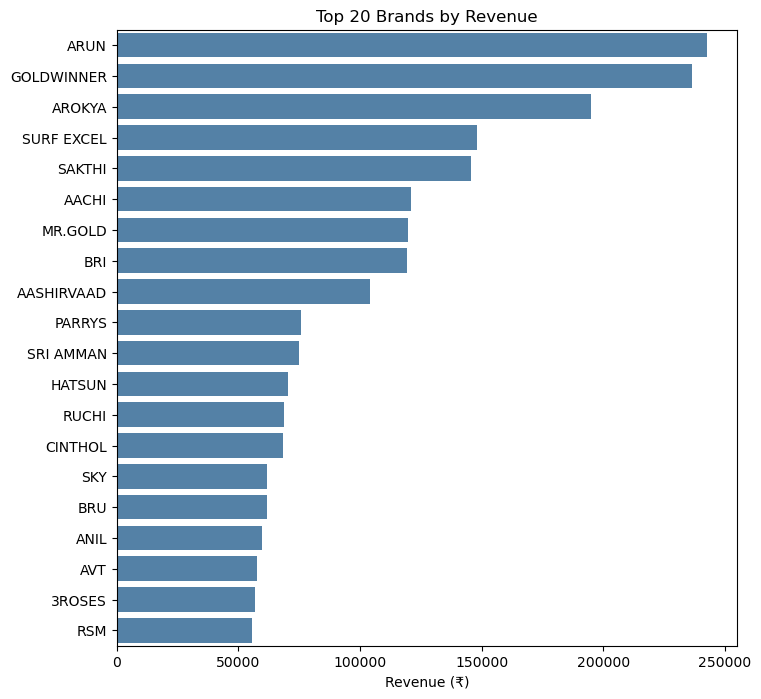

In [14]:
top_brands_clean = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS', 'RAW INGREDIENTS'])].head(20)

plt.figure(figsize=(8, 8))
sns.barplot(data=top_brands_clean, y='Brand', x='Revenue', color='steelblue')
plt.title('Top 20 Brands by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('')
plt.show()

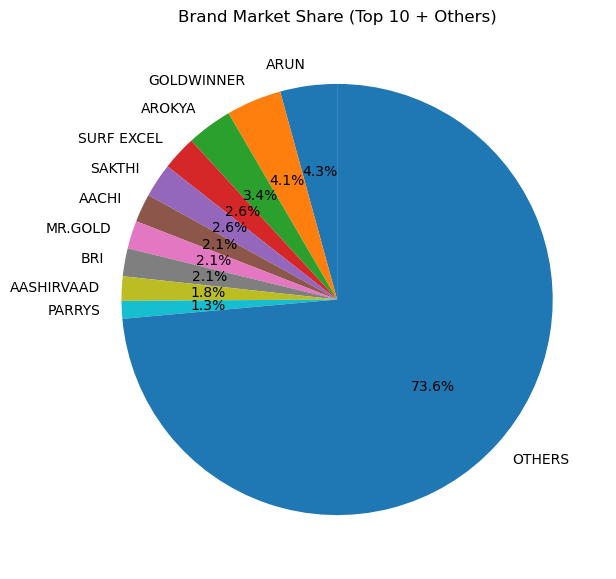

In [15]:
top10 = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS','RAW INGREDIENTS'])].head(10)
others_rev = brand_perf[~brand_perf['Brand'].isin(top10['Brand'].tolist() + ['OTHER BRANDS','RAW INGREDIENTS'])]['Revenue'].sum()

pie_data = list(top10['Revenue']) + [others_rev]
pie_labels = list(top10['Brand']) + ['OTHERS']

plt.figure(figsize=(7, 7))
plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
plt.title('Brand Market Share (Top 10 + Others)')
plt.show()

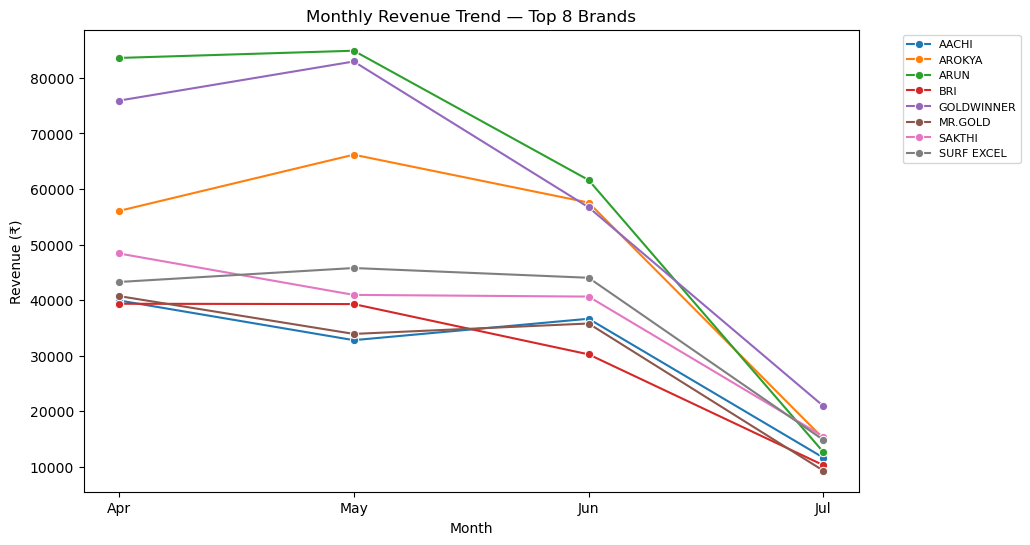

In [16]:
top8 = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS','RAW INGREDIENTS'])].head(8)['Brand'].tolist()
brand_monthly_top = brand_monthly[brand_monthly['Brand'].isin(top8)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=brand_monthly_top, x='Month_name', y='Total', hue='Brand', marker='o')
plt.title('Monthly Revenue Trend — Top 8 Brands')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.show()

## 6. Brand Positioning — Price vs Volume, Loyalty

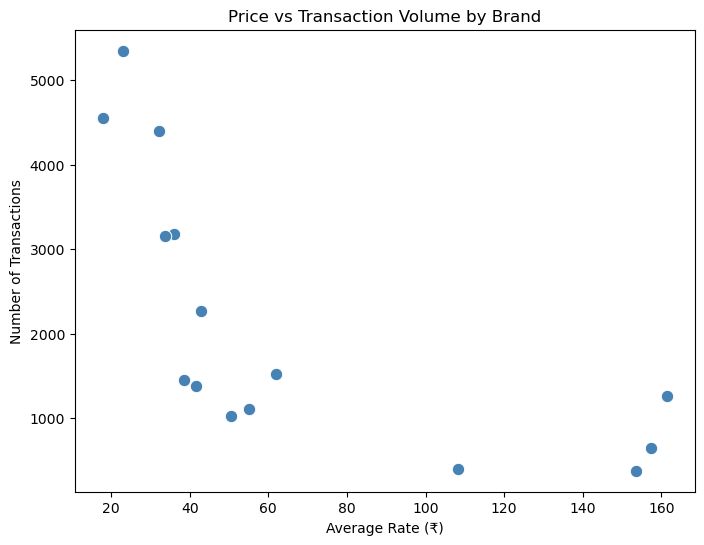

     Brand   Avg_rate  Transactions   Revenue
      ARUN  32.300799          4392 242765.22
GOLDWINNER 161.304434          1263 236533.00
    AROKYA  23.101926          5347 194918.00
SURF EXCEL  42.903700          2270 147965.00
    SAKTHI  35.935203          3173 145487.40
     AACHI  33.785533          3152 121096.50
   MR.GOLD 157.399076           649 119810.00
       BRI  17.937901          4554 119233.90
AASHIRVAAD  61.968442          1521 104022.00
    PARRYS  41.512709          1377  75772.00
 SRI AMMAN  54.959276          1105  74810.00
    HATSUN  38.574586          1448  70563.00
     RUCHI 108.254408           397  68677.00
   CINTHOL  50.507580          1029  68443.80
       SKY 153.570292           377  61813.00


In [17]:
plot_data = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS','RAW INGREDIENTS'])].head(15)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_data, x='Avg_rate', y='Transactions', color='steelblue', s=80)
plt.title('Price vs Transaction Volume by Brand')
plt.xlabel('Average Rate (₹)')
plt.ylabel('Number of Transactions')
plt.show()

print(plot_data[['Brand','Avg_rate','Transactions','Revenue']].to_string(index=False))

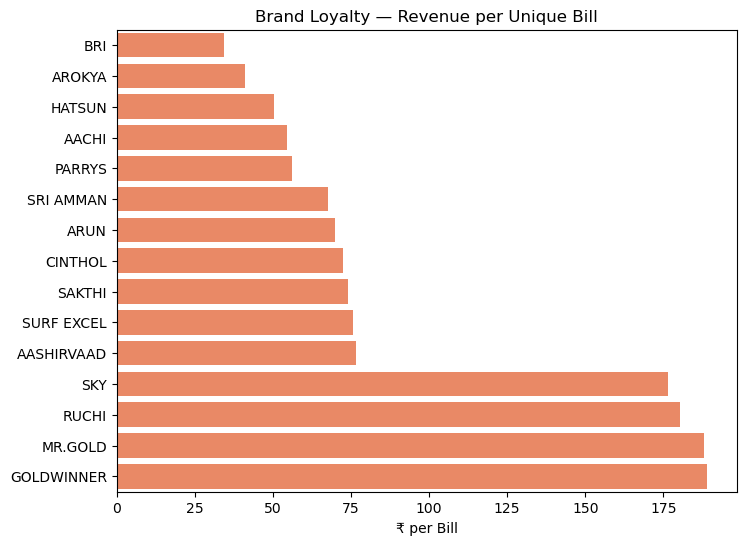

In [18]:
loyalty = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS','RAW INGREDIENTS'])].head(15).sort_values('Rev_per_bill', ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=loyalty, y='Brand', x='Rev_per_bill', color='coral')
plt.title('Brand Loyalty — Revenue per Unique Bill')
plt.xlabel('₹ per Bill')
plt.ylabel('')
plt.show()

## 7. Head-to-Head Category Comparisons

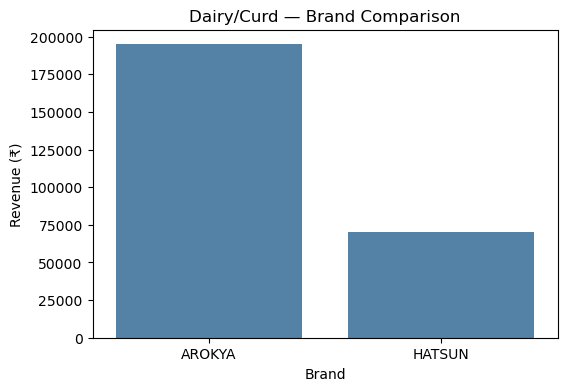

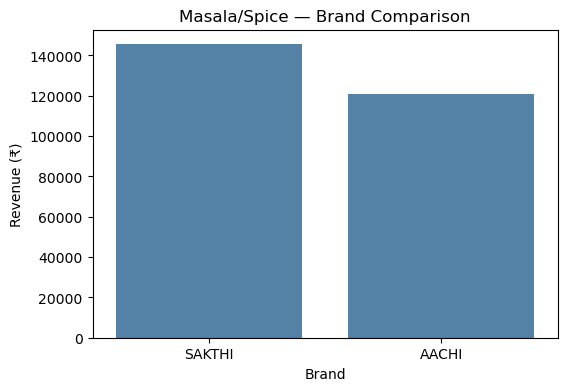

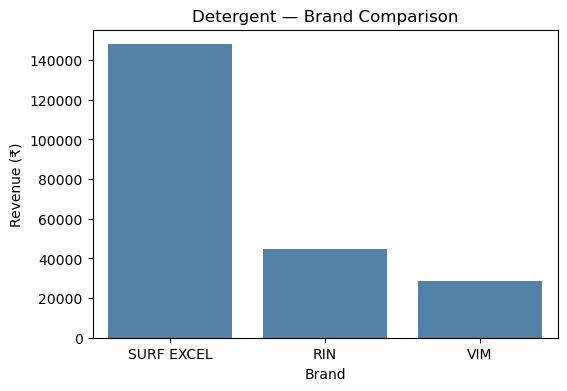

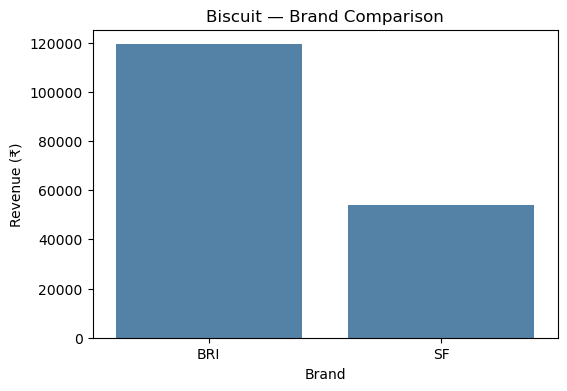

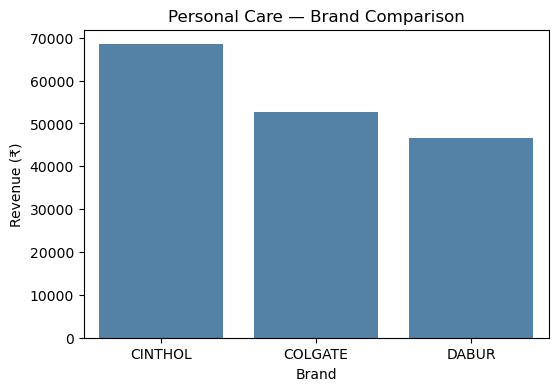

In [20]:
comparisons = {
    'Dairy/Curd'   : ['AROKYA', 'HATSUN'],
    'Masala/Spice' : ['AACHI', 'SAKTHI'],
    'Detergent'    : ['SURF EXCEL', 'VIM', 'RIN'],
    'Biscuit'      : ['BRI', 'SF'],
    'Personal Care'   : ['COLGATE', 'CINTHOL', 'DABUR'],
}

for category, brands in comparisons.items():
    data = brand_perf[brand_perf['Brand'].isin(brands)][['Brand','Revenue']].sort_values('Revenue', ascending=False)
    plt.figure(figsize=(6, 4))
    sns.barplot(data=data, x='Brand', y='Revenue', color='steelblue')
    plt.title(f'{category} — Brand Comparison')
    plt.xlabel('Brand')
    plt.ylabel('Revenue (₹)')
    plt.show()

## 8. Summary & Key Insights

In [21]:
print("=" * 75)
print("  BRAND ANALYSIS SUMMARY")
print("=" * 75)

summary = brand_perf[~brand_perf['Brand'].isin(['OTHER BRANDS','RAW INGREDIENTS'])].head(15)
print(f"\n{'Brand':<20} {'Revenue':>12} {'Share%':>8} {'Bills':>8} {'Products':>10} {'Avg Rate':>10}")
print("-" * 75)
for _, row in summary.iterrows():
    print(f"{row['Brand']:<20} ₹{row['Revenue']:>10,.0f} {row['Market_share_%']:>7.2f}% {row['Unique_bills']:>8,} {row['Num_products']:>10} ₹{row['Avg_rate']:>8.0f}")
print("-" * 75)

top_named = summary.iloc[0]
premium = summary.sort_values('Avg_rate', ascending=False).iloc[0]
footfall = summary.sort_values('Unique_bills', ascending=False).iloc[0]
diverse = summary.sort_values('Num_products', ascending=False).iloc[0]

print(f"\nKEY INSIGHTS")
print(f"  → {top_named['Brand']} leads revenue among named brands (₹{top_named['Revenue']:,.0f})")
print(f"  → {premium['Brand']} has the highest avg rate (₹{premium['Avg_rate']:.0f}) — premium positioning")
print(f"  → {footfall['Brand']} has the most unique bills ({footfall['Unique_bills']:,}) — biggest footfall driver")
print(f"  → {diverse['Brand']} carries the widest range ({diverse['Num_products']} products) — most diverse SKU line")

  BRAND ANALYSIS SUMMARY

Brand                     Revenue   Share%    Bills   Products   Avg Rate
---------------------------------------------------------------------------
ARUN                 ₹   242,765    3.08%    3,483         28 ₹      32
GOLDWINNER           ₹   236,533    3.01%    1,251          6 ₹     161
AROKYA               ₹   194,918    2.48%    4,760          4 ₹      23
SURF EXCEL           ₹   147,965    1.88%    1,955         27 ₹      43
SAKTHI               ₹   145,487    1.85%    1,964         44 ₹      36
AACHI                ₹   121,096    1.54%    2,229         73 ₹      34
MR.GOLD              ₹   119,810    1.52%      637          7 ₹     157
BRI                  ₹   119,234    1.51%    3,469         78 ₹      18
AASHIRVAAD           ₹   104,022    1.32%    1,360         11 ₹      62
PARRYS               ₹    75,772    0.96%    1,350          4 ₹      42
SRI AMMAN            ₹    74,810    0.95%    1,105          1 ₹      55
HATSUN               ₹    70,563